In [1]:
%matplotlib notebook
import torch
import torch.nn as nn
import torch.optim as optim
from dimensionality_reduction import AE, AE_withskip, AE_sparsesh, AE_sparsede, AETrainer

/home/gwb21218/miniconda3/envs/dm2/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ae = AE_sparsede(1,64)
optimi = optim.Adam(ae.parameters(), lr=5e-4, weight_decay=1e-6)
sched = optim.lr_scheduler.StepLR(optimi, 50)
loss_fn = nn.MSELoss()

In [3]:
trainer = AETrainer(ae, optimi, loss_fn, 200, 4, "training_data_15.npz", scheduler=None)

In [4]:
ae

AE_sparsede(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.01)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=Tru

In [5]:
%%time
trainer.load_data()

CPU times: user 43.5 s, sys: 11.7 s, total: 55.2 s
Wall time: 55.2 s


<IPython.core.display.Javascript object>


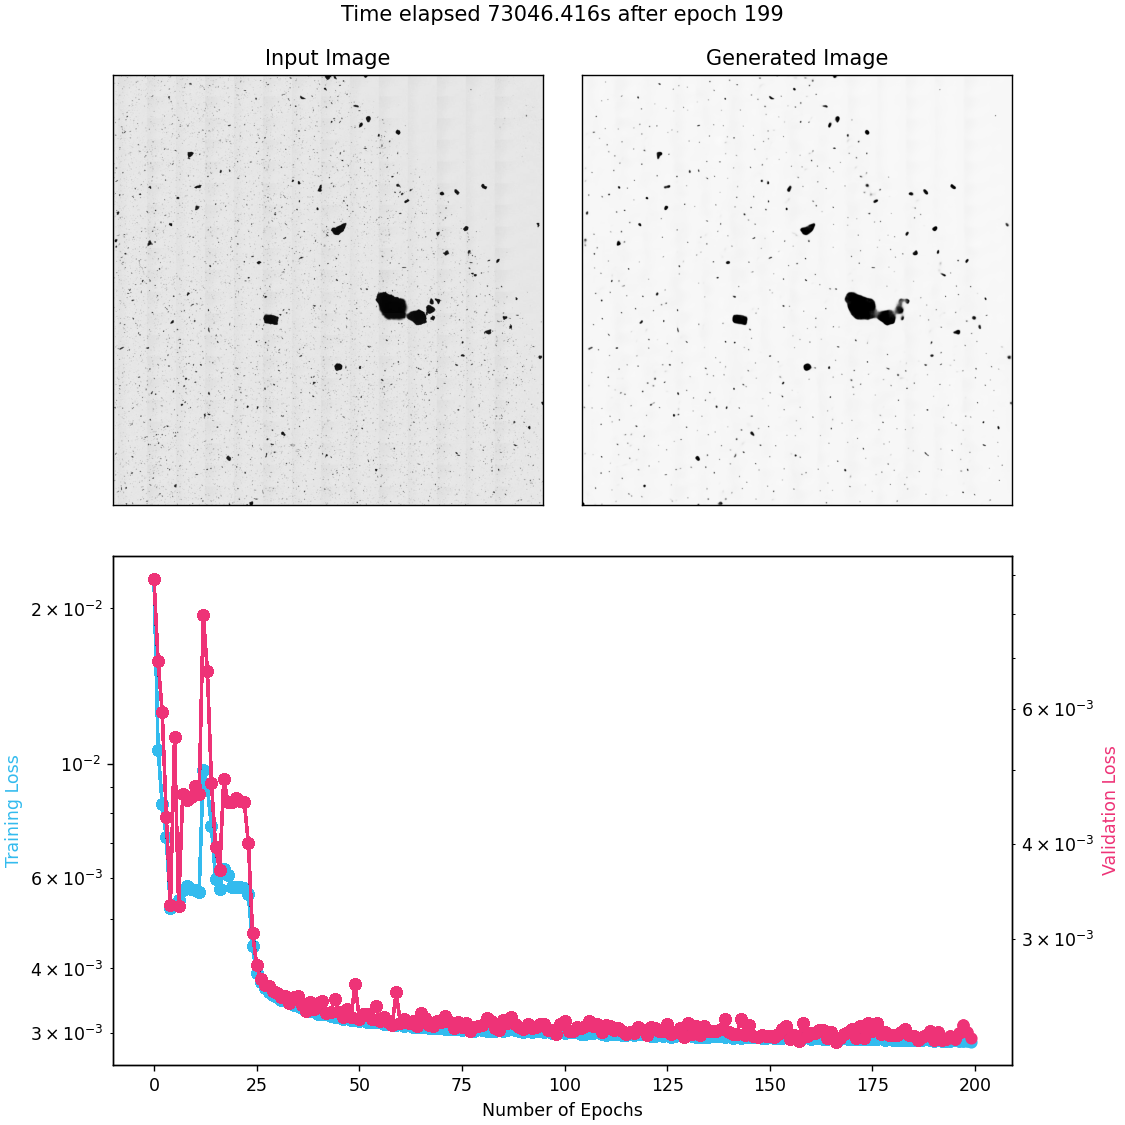

100%|█████████████████████████████████████████████████████████████████████████████████| 504/504 [05:46<00:00,  1.45it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 504/504 [05:46<00:00,  1.45it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 504/504 [05:48<00:00,  1.45it/s]


In [6]:
trainer.myth_trainer()

In [7]:
import numpy as np

In [8]:
trainer.train_losses[-1]

0.002885163528844714

In [9]:
trainer.val_losses[-1]

tensor(0.0022)

In [10]:
np.where(trainer.train_losses == np.min(trainer.train_losses))

(array([199]),)

In [ ]:
trainer.load_checkpoint("199_A10.pth")

In [ ]:
type(trainer.model)

In [ ]:
isinstance(trainer.model, nn.DataParallel)

In [ ]:
enc, dec = list(list(trainer.model.children())[0].children())

In [ ]:
list(enc.children())

In [ ]:
10 // 3

In [ ]:
conv, norm, act = dec[::3], dec[1::3], dec[2::3]

In [ ]:
len(dec) // 3

In [ ]:
dec[1:-2:3], dec[2:-2:3], dec[3:-2:3]

In [ ]:
act

In [ ]:
norm

In [ ]:
act

In [ ]:
from PIL import Image
import numpy as np

In [ ]:
test = Image.open("segmented_dataset/Paracetamol Granular Special_000.jpg")

In [ ]:
test

In [ ]:
plt.figure()
plt.imshow(np.array(test.getdata()).reshape((1024,1024)), cmap="Greys_r")

In [ ]:
im = np.array(test.getdata()).reshape((1024,1024))

In [14]:
with torch.no_grad():
    out = trainer.model(torch.from_numpy(trainer.val_in[-1]).unsqueeze(0).unsqueeze(0).float().cuda()).squeeze().cpu().numpy()

In [12]:
import matplotlib.pyplot as plt

In [ ]:
from skimage.io import imsave
imsave("ae_test.jpeg", (out*255).astype(np.uint8))

<IPython.core.display.Javascript object>


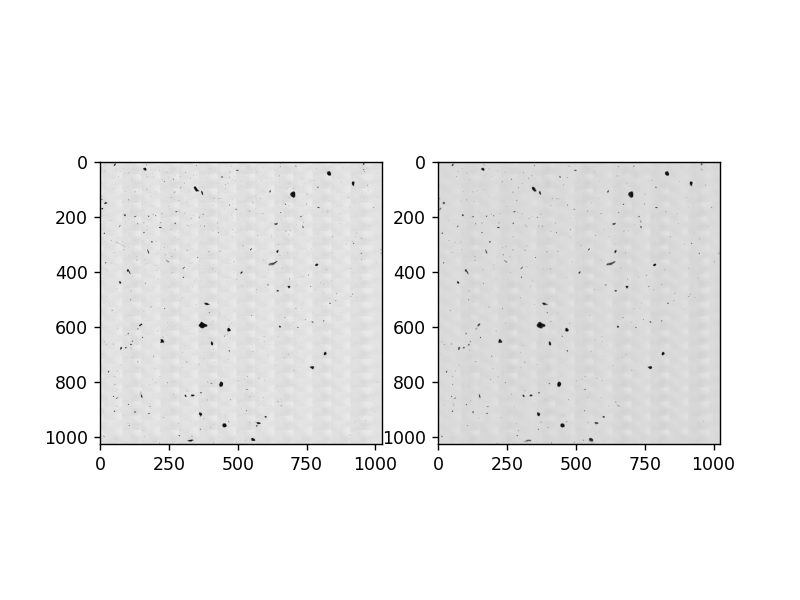

In [15]:
fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(trainer.val_in[-1], cmap="Greys_r")
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(out, cmap="Greys_r")

In [ ]:
import numpy as np

In [16]:
trainer.train_losses[-1]

0.002885163528844714

In [17]:
trainer.val_losses[-1]

tensor(0.0022)

<IPython.core.display.Javascript object>


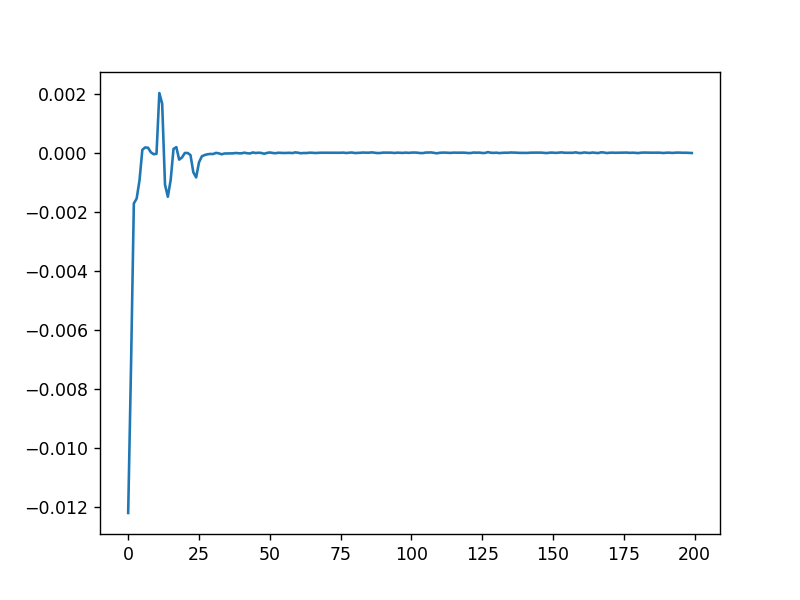

In [18]:
plt.figure()
plt.plot(np.gradient(trainer.train_losses))

In [19]:
np.min(trainer.train_losses)

0.002885163528844714